In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, chi2_contingency, ttest_1samp

In [ ]:
df = pd.read_csv("student_performance.csv")
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [ ]:
def descriptive_stats(data, column):
    series = data[column].dropna()

    stats = {
        "Mean": series.mean(),
        "Median": series.median(),
        "Mode": series.mode().tolist(),
        "Min": series.min(),
        "Max": series.max(),
        "Range": series.max() - series.min(),
        "Standard Deviation": series.std(),
        "Variance": series.var(),
        "Q1": series.quantile(0.25),
        "Q2 (Median)": series.quantile(0.50),
        "Q3": series.quantile(0.75),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "Skewness": series.skew()
    }

    return pd.Series(stats)

In [ ]:
import pandas as pd

df = pd.read_csv("student_performance.csv")

def descriptive_stats(data, column):
    series = data[column].dropna()

    stats = {
        "Mean": series.mean(),
        "Median": series.median(),
        "Mode": series.mode().tolist(),
        "Min": series.min(),
        "Max": series.max(),
        "Range": series.max() - series.min(),
        "Standard Deviation": series.std(),
        "Variance": series.var(),
        "Q1": series.quantile(0.25),
        "Q2 (Median)": series.quantile(0.50),
        "Q3": series.quantile(0.75),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "Skewness": series.skew()
    }

    return pd.Series(stats)


result = descriptive_stats(df, "overall_score")
print(result)

Mean                   64.006172
Median                      64.2
Mode                     [100.0]
Min                         14.5
Max                        100.0
Range                       85.5
Standard Deviation     18.932025
Variance              358.421553
Q1                          49.0
Q2 (Median)                 64.2
Q3                          79.0
IQR                         30.0
Skewness               -0.044512
dtype: object


In [ ]:
sample_150 = df.sample(n=150, random_state=42)
sample_150.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
6868,6869,18,other,private,phd,6.3,82.9,yes,30-60 min,no,notes,71.0,78.7,88.4,86.1,b
24016,12456,15,other,public,high school,2.1,76.1,yes,<15 min,no,notes,41.1,50.8,44.1,44.9,e
9668,9669,15,male,public,graduate,3.7,84.1,no,<15 min,no,notes,73.2,73.5,88.7,66.4,d
13640,13641,16,male,public,no formal,2.4,62.3,yes,30-60 min,yes,coaching,56.1,42.3,55.8,43.9,e
14018,14019,17,other,private,high school,1.0,91.0,yes,>60 min,yes,online videos,49.9,48.9,33.0,37.7,f


In [ ]:
random_stats = descriptive_stats(sample_150, "overall_score")
print(random_stats)

Mean                                                             63.274
Median                                                             65.1
Mode                  [32.6, 46.3, 56.0, 65.3, 65.7, 65.8, 66.4, 74....
Min                                                                18.2
Max                                                               100.0
Range                                                              81.8
Standard Deviation                                            20.130899
Variance                                                     405.253078
Q1                                                               47.325
Q2 (Median)                                                        65.1
Q3                                                                80.45
IQR                                                              33.125
Skewness                                                      -0.069721
dtype: object


In [ ]:
step = len(df) // 150
systematic_sample = df.iloc[::step].head(150)
systematic_sample.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
166,167,15,other,public,post graduate,0.7,63.4,yes,30-60 min,no,group study,18.0,45.5,36.2,37.8,f
332,333,15,other,public,post graduate,3.5,63.8,no,<15 min,no,textbook,60.9,51.2,61.0,61.6,d
498,499,19,female,private,phd,5.4,87.6,yes,30-60 min,yes,notes,83.1,78.1,71.0,70.8,c
664,665,17,female,public,no formal,3.5,77.5,yes,30-60 min,no,mixed,60.2,64.1,45.1,53.9,e


In [ ]:
systematic_stats = descriptive_stats(systematic_sample, "overall_score")
print(systematic_stats)

Mean                  65.119333
Median                     65.0
Mode                    [100.0]
Min                        27.8
Max                       100.0
Range                      72.2
Standard Deviation    18.907116
Variance              357.47902
Q1                        50.75
Q2 (Median)                65.0
Q3                        81.05
IQR                        30.3
Skewness              -0.052469
dtype: object


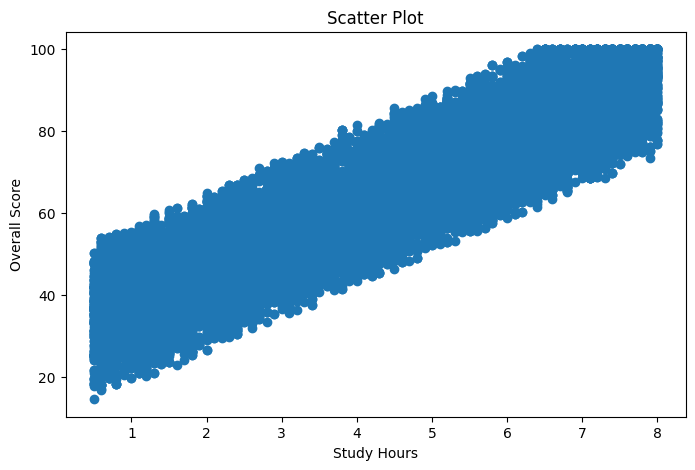

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["study_hours"], df["overall_score"])
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.title("Scatter Plot")
plt.show()

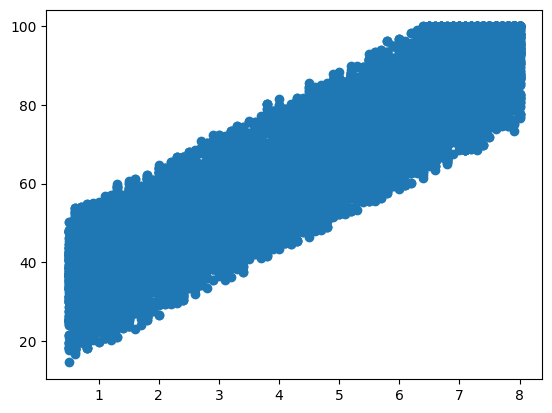

In [ ]:
plt.scatter(df["study_hours"], df["overall_score"])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="pastel")

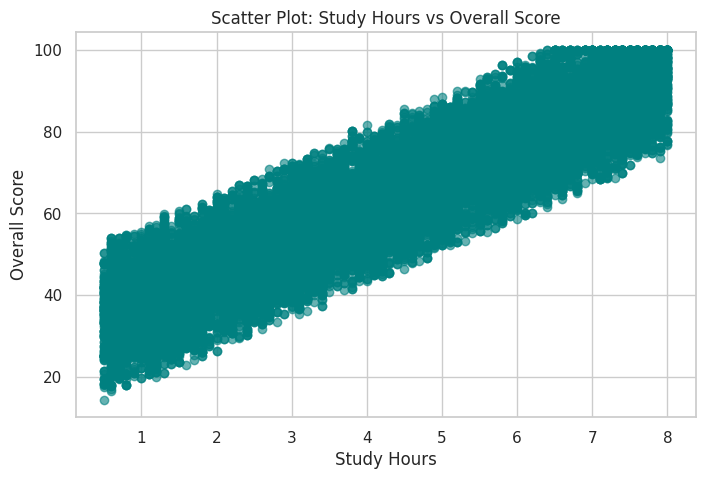

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["study_hours"], df["overall_score"], alpha=0.6, color='teal')

plt.title("Scatter Plot: Study Hours vs Overall Score")
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")

plt.show()

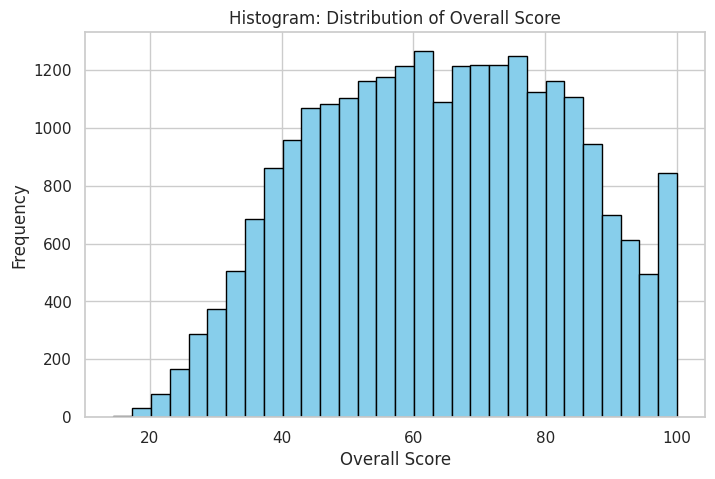

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["overall_score"], bins=30, color='skyblue', edgecolor='black')

plt.title("Histogram: Distribution of Overall Score")
plt.xlabel("Overall Score")
plt.ylabel("Frequency")

plt.show()

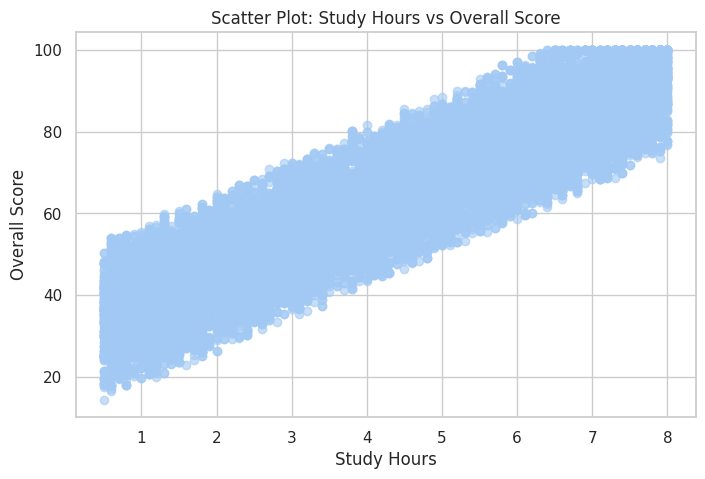

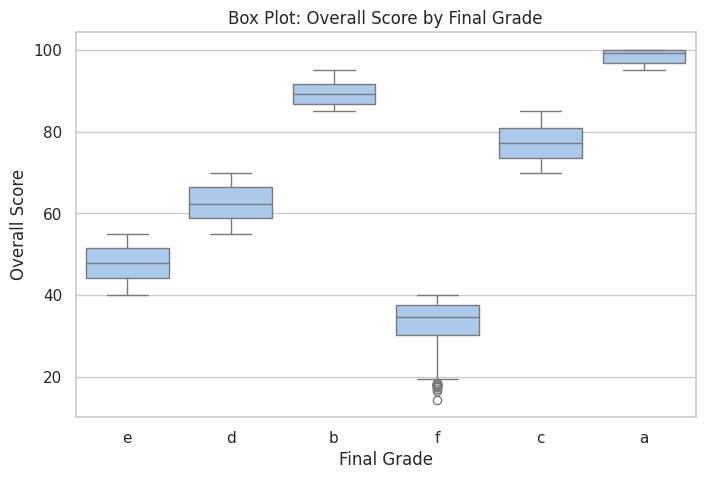

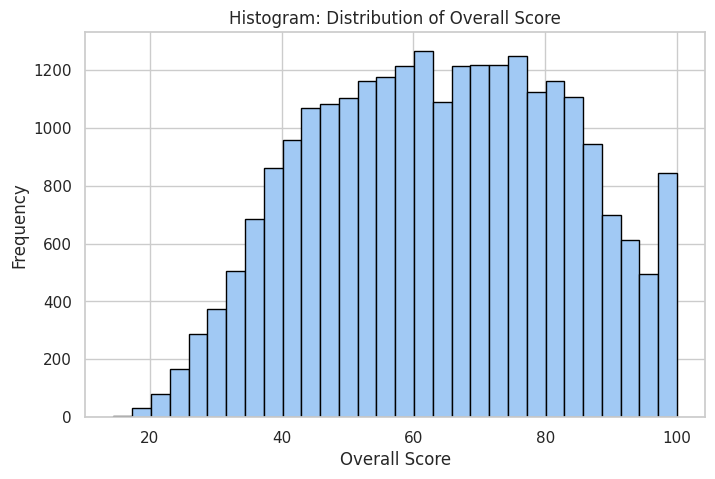

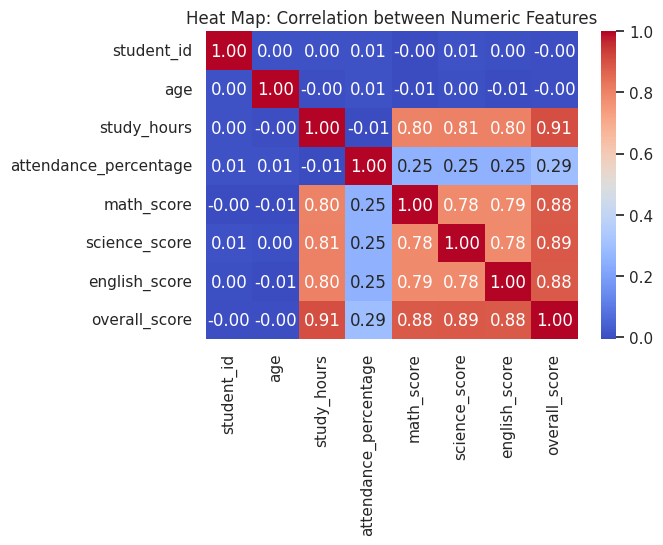

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid", palette="pastel")

# -------- Scatter Plot --------
plt.figure(figsize=(8,5))
plt.scatter(df["study_hours"], df["overall_score"], alpha=0.6)
plt.title("Scatter Plot: Study Hours vs Overall Score")
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.show()


# -------- Box Plot --------
plt.figure(figsize=(8,5))
sns.boxplot(x="final_grade", y="overall_score", data=df)
plt.title("Box Plot: Overall Score by Final Grade")
plt.xlabel("Final Grade")
plt.ylabel("Overall Score")
plt.show()


# -------- Histogram --------
plt.figure(figsize=(8,5))
plt.hist(df["overall_score"], bins=30, edgecolor='black')
plt.title("Histogram: Distribution of Overall Score")
plt.xlabel("Overall Score")
plt.ylabel("Frequency")
plt.show()


# -------- Heat Map --------
plt.figure(figsize=(6,4))
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heat Map: Correlation between Numeric Features")
plt.show()

In [ ]:
from scipy.stats import pearsonr

r, p = pearsonr(df["study_hours"], df["overall_score"])

print("Pearson Correlation:", r)
print("p-value:", p)

if p < 0.05:
    print("Significant relationship between Study Hours and Overall Score")
else:
    print("No significant relationship between Study Hours and Overall Score")

Pearson Correlation: 0.9057714454088278
p-value: 0.0
Significant relationship between Study Hours and Overall Score


In [ ]:
from scipy.stats import spearmanr

education_map = {
    "none": 0,
    "high school": 1,
    "diploma": 2,
    "bachelor": 3,
    "master": 4,
    "phd": 5
}

df["parent_education_num"] = df["parent_education"].str.lower().map(education_map)

data = df[["parent_education_num", "overall_score"]].dropna()

rho, p = spearmanr(data["parent_education_num"], data["overall_score"])

print("Spearman Correlation:", rho)
print("p-value:", p)

if p < 0.05:
    print("Significant relationship between Parent Education and Overall Score")
else:
    print("No significant relationship between Parent Education and Overall Score")

Spearman Correlation: 0.003965077183550175
p-value: 0.656318978133548
No significant relationship between Parent Education and Overall Score


In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["final_grade"], df["gender"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Significant relationship between Final Grade and Gender")
else:
    print("No significant relationship between Final Grade and Gender")

Chi-square: 18.14632631270717
p-value: 0.052544920828117625
No significant relationship between Final Grade and Gender


In [ ]:
from scipy.stats import ttest_1samp

population_mean = df["overall_score"].mean()

t_stat, p = ttest_1samp(sample_150["overall_score"], population_mean)

print("Population Mean:", population_mean)
print("Sample Mean:", sample_150["overall_score"].mean())
print("T-statistic:", t_stat)
print("p-value:", p)

if p > 0.05:
    print("Sample represents the population")
else:
    print("Sample does NOT represent the population")

Population Mean: 64.006172
Sample Mean: 63.274
T-statistic: -0.4454465349254425
p-value: 0.6566436056014051
Sample represents the population
